# Comparison with QDD via subsystem trace distance
*February 05, 2026*

This notebook compares:

- **Our least-squares DD** sequence (optimized segment durations for a fixed Pauli-frame pattern)
- **QDD** (quadratic dynamical decoupling) built from nested UDD sequences

using a **subsystem trace-distance** metric on the system state,
averaged over random product pure initial states (Monte Carlo).

The overall structure follows the same style as the main notebook/PDF:
1) model and objective, 2) sequence construction, 3) simulation, 4) QDD comparison.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dd.pauli_frames import pattern_frames
from dd.moments_opt import build_solutions
from dd.hamiltonian import rand_hermitian, H_lab, make_free_evolver
from dd.pulses_seq import build_pulses, compile_sequence, unitary_sequence_pulse_compiled
from dd.qdd import build_qdd_pulse_list_rel, propagator_qdd_compiled
from dd.benchmarks import run_monte_carlo_compare

np.set_printoptions(precision=17, suppress=False)


## 1. Model and weak-coupling objective

We consider a system–bath Hamiltonian with ideal, instantaneous Pauli $\pi$-pulses on the system.
In the weak-coupling regime, the goal is to design a pulse sequence such that linear-in-$J$ terms
vanish through order $K$ in time, yielding a leading scaling of the form

$$\|U(T)-U_0(T)\| = O(JT^{K+1}) + O(J^2T^2).$$

In the main notebook we validated this at the unitary level (operator norm).  
Here we validate **at the reduced-state level** by comparing the reduced system states
under $J=0$ and $J>0$:

$$D(\rho_S^{\mathrm{DD}}(T),\rho_S^{\mathrm{id}}(T)) := \tfrac12\|\rho_S^{\mathrm{DD}}(T)-\rho_S^{\mathrm{id}}(T)\|_1.$$


## 2. Build our least-squares DD timings (choose $K_{\mathrm{our}}=5$)

We reuse the least-squares construction from the main notebook, but only solve for the single
order needed for this comparison to keep runtime reasonable.


In [2]:
# -----------------------------
# Configuration
# -----------------------------
rng = np.random.default_rng(123)

dS = 2
nB = 2  # bath dimension
dB = nB

Ts = np.logspace(-2.0, 0.5, 14)
J_values = [1e-3, 1e-4, 1e-5]

K_our = 5
K_qdd = 3
num_samples = 100

# -----------------------------
# Random bath/coupling operators (fixed across Monte Carlo)
# -----------------------------
HB = rand_hermitian(nB, rng)
Bx = rand_hermitian(nB, rng)
By = rand_hermitian(nB, rng)
Bz = rand_hermitian(nB, rng)

# -----------------------------
# Build our optimized timings for K_our
# -----------------------------
solutions = build_solutions(
    k_min=K_our,
    k_max=K_our,
    T_norm=1.0,
    frame_cycle=("I", "X", "Y", "Z"),
    restarts=8,
    seed_base=100,
    max_nfev=100000,
    compile_sequence_fn=compile_sequence,
    pattern_frames_fn=pattern_frames,
    verbose=True,
)

frames = solutions[K_our]["frames"]
seq_our = solutions[K_our]["seq"]
durs_our = solutions[K_our]["durs_frac"]  # fractions, sum to 1

print("Our DD: K_our =", K_our, "segments =", len(durs_our), "pulses =", 3*K_our)


[k=5] L=16, residual_norm=1.968e-12, sum(durs)=1.000000000000
Our DD: K_our = 5 segments = 16 pulses = 15


## 3. QDD construction (choose $K_{\mathrm{qdd}}=3$)

QDD is built by nesting an $N_x$-pulse UDD sequence inside each interval of an $N_z$-pulse UDD sequence.
In this notebook we use the common choice $N_x=N_z=K_{\mathrm{qdd}}$.

We precompute the **relative pulse times** on $[0,1]$ once, then scale by $T$.


In [3]:
Nx = Nz = K_qdd
pulse_list_rel = build_qdd_pulse_list_rel(Nx, Nz)
print("QDD: K_qdd =", K_qdd, "Nx=Nz=", Nx, "num pulses =", len(pulse_list_rel))


QDD: K_qdd = 3 Nx=Nz= 3 num pulses = 15


## 4. Monte Carlo trace-distance benchmark

For each $T$ and coupling strength $J$, we sample random product pure initial states
$\rho_{SB}(0)=|\psi\rangle\langle\psi|_S\otimes|\phi\rangle\langle\phi|_B$,
evolve under $J=0$ and $J>0$ for both sequences, reduce to the system, and compute trace distance.

We report **mean ± std** across samples.


In [4]:
# Precompute system pulses
pulses = build_pulses(nB)
P_X = pulses[0]
P_Z = pulses[2]

# Precompute ideal (J=0) free evolver once
Ufree0 = make_free_evolver(H_lab(0.0, HB, Bx, By, Bz))

results = {}  # map J -> (mean_our, std_our, mean_qdd, std_qdd)

for J in J_values:
    UfreeJ = make_free_evolver(H_lab(J, HB, Bx, By, Bz))

    # closures producing unitaries (ideal vs noisy)
    def unitary_our(T, ideal: bool):
        return unitary_sequence_pulse_compiled(
            seq_our, durs_our, T,
            Ufree0 if ideal else UfreeJ,
            pulses
        )

    def unitary_qdd(T, ideal: bool):
        return propagator_qdd_compiled(
            Ufree=(Ufree0 if ideal else UfreeJ),
            pulseX=P_X,
            pulseZ=P_Z,
            T=T,
            pulse_list_rel=pulse_list_rel,
        )

    print(f"Running Monte Carlo for J = {J:.0e} ...")
    mean_our, std_our, mean_qdd, std_qdd = run_monte_carlo_compare(
        Ts=Ts,
        num_samples=num_samples,
        rng=rng,
        dS=dS,
        dB=dB,
        unitary_our=unitary_our,
        unitary_qdd=unitary_qdd,
    )
    results[J] = (mean_our, std_our, mean_qdd, std_qdd)


Running Monte Carlo for J = 1e-03 ...
Running Monte Carlo for J = 1e-04 ...
Running Monte Carlo for J = 1e-05 ...


## 5. Plot: 3 panels for $J=10^{-3},10^{-4},10^{-5}$ (mean ± std)

We plot the trace-distance error vs $T$ on a log–log scale.


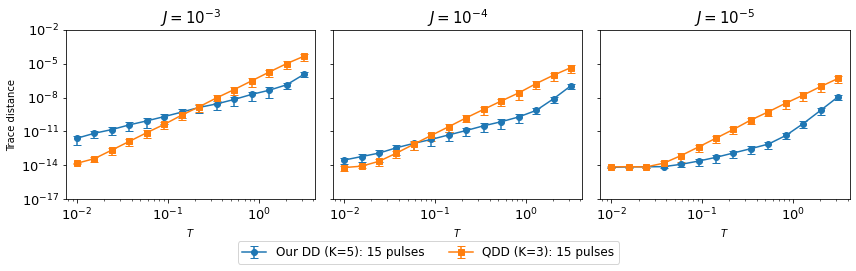

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

markers = ["o", "s"]

for ax, J in zip(axes, J_values):
    mean_our, std_our, mean_qdd, std_qdd = results[J]

    ax.errorbar(
        Ts, mean_our, yerr=std_our,
        fmt=markers[0] + "-",
        capsize=4,
        label=f"Our DD (K={K_our}): {3*K_our} pulses"
    )
    ax.errorbar(
        Ts, mean_qdd, yerr=std_qdd,
        fmt=markers[1] + "-",
        capsize=4,
        label=f"QDD (K={K_qdd}): {len(pulse_list_rel)} pulses"
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(rf"$J=10^{{{int(np.log10(J))}}}$", fontsize=15)
    ax.set_ylim(1e-17, 1e-2)

axes[0].set_ylabel("Trace distance")
for ax in axes:
    ax.set_xlabel(r"$T$")
    ax.tick_params(axis='both', which='major', labelsize=13)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    fontsize=12,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, 0.05)
)
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()
